# Τμηματοποίηση k-Means της Συμπεριφοράς Συνδρομητών με την PROC FASTCLUS

## Περίληψη για τη Διοίκηση

Αυτό το notebook τμηματοποιεί μια συνθετική βάση 100 συνδρομητών κινητής τηλεφωνίας σε συμπεριφορικές συστάδες χρησιμοποιώντας την `PROC FASTCLUS`, τη διαδικασία k-means ομαδοποίησης της Base SAS. Επτά χαρακτηριστικά χρήσης τυποποιούνται σε z-scores με την `PROC STDIZE`, ώστε οι μεταβλητές μεγάλου μεγέθους (λεπτά ομιλίας, αριθμός SMS) να μην κυριαρχούν στην Ευκλείδεια απόσταση, και στη συνέχεια η `PROC FASTCLUS` προσαρμόζει τρεις συστάδες. Η διαδικασία αναφέρει την εντός-συστάδας RMS απόκλιση, ένα συνολικό R-τετράγωνο και pseudo-F που ποσοτικοποιούν πόσο καλά η τμηματοποίηση διαχωρίζει τη βάση (εδώ ένα συνολικό R-τετράγωνο 0,575 και pseudo-F 65,75), και γράφει έναν βαθμολογημένο πίνακα με μια ετικέτα `CLUSTER` για κάθε συνδρομητή. Συγχωνεύουμε αυτές τις ετικέτες πίσω στα δεδομένα αρχικής κλίμακας, κάνουμε προφίλ των προσωπικοτήτων, και παραδίδουμε τις αναθέσεις στην επόμενη φάση ενεργοποίησης.

## Πηγές Δεδομένων

| Σύνολο Δεδομένων | Περιγραφή | Γραμμές | Βασικές Μεταβλητές |
| ------- | ----------- | ---: | ------------- |
| `subscribers` | Συνθετικό μηνιαίο στιγμιότυπο συμπεριφοράς για μια βάση συνδρομητών κινητής τηλεφωνίας, δημιουργημένο εν σειρά με `call streaminit` / `rand()`. Τρεις λανθάνοντες τύποι συμπεριφοράς (υψηλή χρήση δεδομένων, κεντρικά στη φωνή, χαμηλή χρήση) αναμειγνύονται με θόρυβο. | 100 | `subscriber_id`, `tenure_months`, `monthly_data_gb`, `voice_minutes`, `sms_count`, `arpu`, `intl_minutes`, `support_calls`, `data_plan` (ονομαστική), `region` (ονομαστική) |

# Τμηματοποίηση k-Means της Συμπεριφοράς Συνδρομητών

**Κλάδος:** Τηλεπικοινωνίες &nbsp;|&nbsp; **Διαδικασία:** `PROC FASTCLUS` (k-means ομαδοποίηση Base SAS)

Οι πάροχοι κινητής τηλεφωνίας έχουν συνδρομητές των οποίων η μηνιαία συμπεριφορά -- όρεξη για δεδομένα, συνήθειες ομιλίας, δαπάνη, και τριβή με την υποστήριξη -- εμπίπτει σε λίγα αναγνωρίσιμα πρότυπα. Η ανακάλυψη αυτών των προτύπων επιτρέπει στην επιχείρηση να προσαρμόσει ενέργειες διατήρησης, να προτείνει τα σωστά πακέτα, και να αποκτήσει παρόμοιους πελάτες. Αυτό το notebook χτίζει μια συμπεριφορική τμηματοποίηση από άκρη σε άκρη: δημιουργεί ένα ρεαλιστικό στιγμιότυπο συνδρομητών, τυποποιεί τα χαρακτηριστικά, αφήνει την `PROC FASTCLUS` να προσαρμόσει τις συστάδες, βαθμολογεί κάθε συνδρομητή, και κάνει προφίλ των τμημάτων σε αξιοποιήσιμες προσωπικότητες. Η `PROC FASTCLUS` είναι σχεδιασμένη ακριβώς για αυτή την εργασία ασύνδετων k-means και κλιμακώνεται σε πολύ μεγάλες βάσεις περνώντας μία φορά πάνω από τα δεδομένα αντί να χτίζει έναν πλήρη πίνακα αποστάσεων.

## 1. Δημιουργία συνθετικής βάσης συνδρομητών

Προσομοιώνουμε 100 συνδρομητές που προέρχονται από τρία λανθάνοντα αρχέτυπα συμπεριφοράς -- **streamers υψηλής χρήσης δεδομένων**, **παραδοσιακούς χρήστες κεντρικά στη φωνή**, και πελάτες **ελαφριάς/χαμηλής χρήσης** -- και στη συνέχεια αναμειγνύουμε θόρυβο ώστε τα όρια να είναι θολά (όπως συμβαίνει και στην πραγματικότητα). Κάθε συνδρομητής φέρει επίσης δύο κατηγορικά χαρακτηριστικά, `data_plan` και `region`, που χρησιμοποιούμε αργότερα για να κάνουμε *προφίλ* των τμημάτων. Ο σπόρος τυχαιότητας κάνει τα δεδομένα αναπαραγώγιμα.

In [1]:
/* -----------------------------------------------------------
   Συνθετικό στιγμιότυπο 100 συνδρομητών κινητής τηλεφωνίας.
   Τρία λανθάνοντα αρχέτυπα συμπεριφοράς + θόρυβος, συν δύο
   κατηγορικά χαρακτηριστικά για το προφίλ των τμημάτων.
   ----------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ subscribers;
    CALL streaminit(20260531);
    LENGTH data_plan $40 region $40;

    ΕΠΑΝΑΛΗΨΗ subscriber_id = 100001 ΕΩΣ 100100;

        /* λανθάνον αρχέτυπο: 1=υψηλή χρήση δεδομένων, 2=φωνή, 3=χαμηλή χρήση */
        u = rand('uniform');
        ΕΑΝ      u < 0.38 ΤΟΤΕ archetype = 1;
        ΑΛΛΙΩΣ ΕΑΝ u < 0.70 ΤΟΤΕ archetype = 2;
        ΑΛΛΙΩΣ                  archetype = 3;

        tenure_months = MAX(1, round(rand('gamma', 2.2) * 12));

        ΕΑΝ archetype = 1 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;             /* streamer υψηλής χρήσης δεδομένων */
            monthly_data_gb = MAX(0.5, rand('normal', 42, 11));
            voice_minutes   = MAX(0,   rand('normal', 180, 70));
            sms_count       = MAX(0,   round(rand('normal', 60, 30)));
            intl_minutes    = MAX(0,   rand('normal', 22, 14));
            arpu            = MAX(15,  rand('normal', 78, 14));
            support_calls   = rand('poisson', 0.8);
            planpick = ifn(rand('uniform') < 0.65, 3, 2);
        ΤΕΛΟΣ;
        ΑΛΛΙΩΣ ΕΑΝ archetype = 2 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;        /* κεντρικά στη φωνή */
            monthly_data_gb = MAX(0.2, rand('normal', 9, 4));
            voice_minutes   = MAX(0,   rand('normal', 620, 160));
            sms_count       = MAX(0,   round(rand('normal', 210, 80)));
            intl_minutes    = MAX(0,   rand('normal', 95, 45));
            arpu            = MAX(12,  rand('normal', 55, 12));
            support_calls   = rand('poisson', 1.6);
            planpick = ifn(rand('uniform') < 0.55, 2, 1);
        ΤΕΛΟΣ;
        ΑΛΛΙΩΣ ΕΠΑΝΑΛΗΨΗ;                              /* χαμηλή χρήση */
            monthly_data_gb = MAX(0.1, rand('normal', 3, 1.5));
            voice_minutes   = MAX(0,   rand('normal', 110, 50));
            sms_count       = MAX(0,   round(rand('normal', 35, 20)));
            intl_minutes    = MAX(0,   rand('normal', 6, 6));
            arpu            = MAX(8,   rand('normal', 26, 7));
            support_calls   = rand('poisson', 0.5);
            planpick = ifn(rand('uniform') < 0.70, 1, 2);
        ΤΕΛΟΣ;

        ΕΑΝ      planpick = 1 ΤΟΤΕ data_plan = 'Προπληρωμένο';
        ΑΛΛΙΩΣ ΕΑΝ planpick = 2 ΤΟΤΕ data_plan = 'Συμβόλαιο';
        ΑΛΛΙΩΣ                       data_plan = 'Απεριόριστο';

        region_idx = rand('table', 0.30, 0.28, 0.22, 0.20);
        ΕΑΝ      region_idx = 1 ΤΟΤΕ region = 'Βόρεια';
        ΑΛΛΙΩΣ ΕΑΝ region_idx = 2 ΤΟΤΕ region = 'Νότια';
        ΑΛΛΙΩΣ ΕΑΝ region_idx = 3 ΤΟΤΕ region = 'Ανατολικά';
        ΑΛΛΙΩΣ                         region = 'Δυτικά';

        /* στρογγυλοποίηση σε ακρίβεια αναφοράς */
        monthly_data_gb = round(monthly_data_gb, 0.1);
        voice_minutes   = round(voice_minutes,   1);
        intl_minutes    = round(intl_minutes,    1);
        arpu            = round(arpu,            0.01);

        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;

    ΚΡΑΤΗΣΗ subscriber_id tenure_months monthly_data_gb voice_minutes
         sms_count intl_minutes arpu support_calls data_plan region;
ΕΚΤΕΛΕΣΗ;


NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Επισκόπηση των κατανομών χαρακτηριστικών

Πριν από την ομαδοποίηση, εξετάζουμε την κλίμακα και τη διασπορά κάθε συμπεριφορικού χαρακτηριστικού. Οι εντελώς διαφορετικές μονάδες -- gigabyte, λεπτά, δολάρια, πλήθη -- είναι ακριβώς ο λόγος που τυποποιούμε τις εισόδους διαστήματος πριν από την ομαδοποίηση· διαφορετικά, μεταβλητές μεγάλου μεγέθους όπως η `voice_minutes` θα κυριαρχούσαν στην Ευκλείδεια απόσταση που ελαχιστοποιεί η `PROC FASTCLUS`.

                                                  The MEANS Procedure

 Variable         Label                                                    N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 -------------------------------------------------------------------------------------------------------------------------------------------------------------------------
 tenure_months    Διάρκεια Συνδρομής (μήνες)                             100        27.6        18.9         3.0             13.0        22.0             37.5        98.0
 monthly_data_gb  Μηνιαία Δεδομένα (GB)                                  100        18.2        18.9         0.1              3.7         9.6             31.5        67.2
 voice_minutes    Λεπτά Ομιλίας                                          100       304.2       236.6         0.0            125.0       217.0            527.5       912.0
 sms_count        Αριθμός SMS                                            1


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_data_plan.spec.json
NOTE: ODS plot written: freq_region.spec.json
NOTE: PROC FREQ statement used.


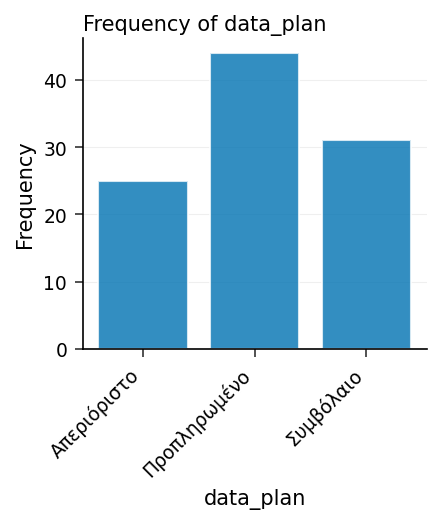

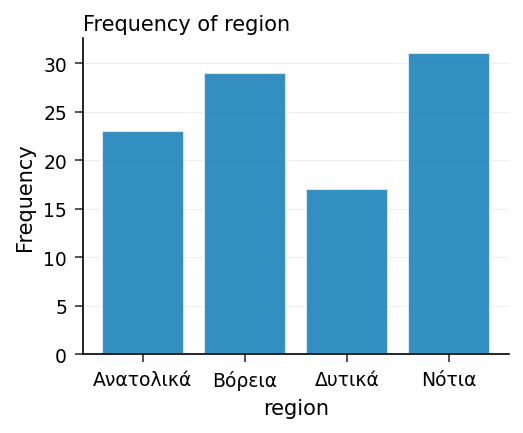

In [2]:
/* Συνοπτικά στατιστικά για τις εισόδους ομαδοποίησης */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
    ΕΤΙΚΕΤΑ tenure_months='Διάρκεια Συνδρομής (μήνες)' monthly_data_gb='Μηνιαία Δεδομένα (GB)'
          voice_minutes='Λεπτά Ομιλίας' sms_count='Αριθμός SMS' intl_minutes='Διεθνή Λεπτά'
          arpu='ARPU ($)' support_calls='Κλήσεις Υποστήριξης';
    ΜΕΤΑΒΛΗΤΗ tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
ΕΚΤΕΛΕΣΗ;

/* Συχνότητα των δύο κατηγορικών εισόδων */
ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=subscribers;
    ΕΤΙΚΕΤΑ data_plan='Πρόγραμμα' region='Περιοχή';
    TABLES data_plan region / nocum;
ΕΚΤΕΛΕΣΗ;

## 3. Τυποποίηση των χαρακτηριστικών σε z-scores

Η `PROC FASTCLUS` ελαχιστοποιεί την Ευκλείδεια απόσταση, οπότε μια μεταβλητή μετρημένη σε εκατοντάδες λεπτά θα πνίγει μία μετρημένη σε μονοψήφια gigabyte. Η `PROC STDIZE` με `METHOD=STD` επανακλιμακώνει κάθε χαρακτηριστικό διαστήματος σε μέσο όρο 0 και τυπική απόκλιση 1, δίνοντας σε κάθε συμπεριφορά ίσο βάρος στην απόσταση. Οι κατηγορικές στήλες και το αναγνωριστικό περνούν αμετάβλητα ώστε να μπορούμε να κάνουμε προφίλ των συστάδων στην αρχική τους κλίμακα αργότερα.

In [3]:
/* τυποποίηση σε z-scores· αναγνωριστικά και κατηγορικά περνούν αμετάβλητα */
ΔΙΑΔΙΚΑΣΙΑ stdize ΔΕΔΟΜΕΝΑ=subscribers out=subs_std METHOD=std;
    ΕΤΙΚΕΤΑ tenure_months='Διάρκεια Συνδρομής (μήνες)' monthly_data_gb='Μηνιαία Δεδομένα (GB)'
          voice_minutes='Λεπτά Ομιλίας' sms_count='Αριθμός SMS' intl_minutes='Διεθνή Λεπτά'
          arpu='ARPU ($)' support_calls='Κλήσεις Υποστήριξης';
    ΜΕΤΑΒΛΗΤΗ tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
ΕΚΤΕΛΕΣΗ;


NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std


## 4. Προσαρμογή της τμηματοποίησης k-means

Προσαρμόζουμε τρία τμήματα με την `PROC FASTCLUS`. Το `MAXCLUSTERS=3` ορίζει το *k*· το `MAXITER=20` επιτρέπει στα κέντρα των συστάδων να επαναλαμβάνονται μέχρι σύγκλιση. Η διαδικασία αναφέρει μια **Σύνοψη Συστάδων** (μέγεθος και εντός-συστάδας RMS απόκλιση ανά συστάδα), **Στατιστικά για Μεταβλητές** (το R-τετράγωνο που συνεισφέρει κάθε χαρακτηριστικό), ένα **συνολικό R-τετράγωνο** και **pseudo-F** που μετρούν πόσο καθαρά οι τρεις συστάδες διαχωρίζουν τη βάση, και **Μέσους Όρους Συστάδων** στην τυποποιημένη κλίμακα. Το `OUT=scored` γράφει τις γραμμές εισόδου πίσω με μια ετικέτα `CLUSTER` και την `DISTANCE` κάθε συνδρομητή από τον σπόρο της συστάδας του.

In [4]:
/* Προσαρμογή k-means στα τυποποιημένα χαρακτηριστικά: 3 τμήματα. */
ΔΙΑΔΙΚΑΣΙΑ FASTCLUS ΔΕΔΟΜΕΝΑ=subs_std maxclusters=3 MAXITER=20 out=scored;
    ΕΤΙΚΕΤΑ tenure_months='Διάρκεια Συνδρομής (μήνες)' monthly_data_gb='Μηνιαία Δεδομένα (GB)'
          voice_minutes='Λεπτά Ομιλίας' sms_count='Αριθμός SMS' intl_minutes='Διεθνή Λεπτά'
          arpu='ARPU ($)' support_calls='Κλήσεις Υποστήριξης';
    ΜΕΤΑΒΛΗΤΗ tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
ΕΚΤΕΛΕΣΗ;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=20                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  36         0.5293             2.6279              3         3.0809
2                  34         0.7925             3.4184              3         3.5916
3                  30         0.6295             3.9300              1         3.0809

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 7 variables, 3 clusters using k-means


## 5. Επισύναψη ετικετών τμήματος στα δεδομένα αρχικής κλίμακας

Ο βαθμολογημένος πίνακας κρατά τα τυποποιημένα χαρακτηριστικά· για το προφίλ θέλουμε οι συστάδες να περιγράφονται σε πραγματικά gigabyte, λεπτά, και δολάρια. Συγχωνεύουμε την ετικέτα `CLUSTER` πίσω στον αρχικό πίνακα `subscribers` κατά `subscriber_id`, και μετά κάνουμε την πρώτη ερώτηση που κάνει πάντα το μάρκετινγκ: *πόσο μεγάλο είναι κάθε τμήμα;*

                                                   The FREQ Procedure

Τμήμα         Frequency    Percent
-----------------------------------
1                    36     36.00
2                    34     34.00
3                    30     30.00



NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote clus_assign (100 rows, 12 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


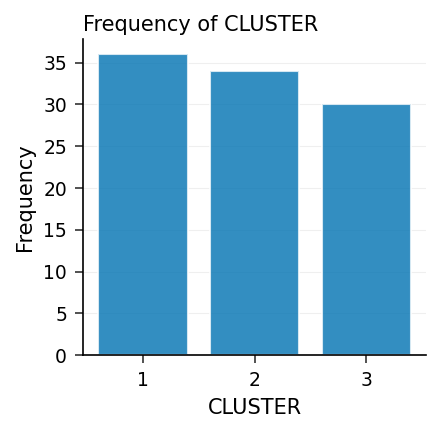

In [5]:
/* μεταφορά της ετικέτας τμήματος πίσω στα δεδομένα αρχικής κλίμακας */
ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=scored(ΚΡΑΤΗΣΗ=subscriber_id CLUSTER distance) out=clus_assign;
    ΚΑΤΑ subscriber_id;
ΕΚΤΕΛΕΣΗ;
ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=subscribers out=subs_sorted;
    ΚΑΤΑ subscriber_id;
ΕΚΤΕΛΕΣΗ;
ΔΕΔΟΜΕΝΑ profile;
    ΣΥΓΧΩΝΕΥΣΗ subs_sorted clus_assign;
    ΚΑΤΑ subscriber_id;
ΕΚΤΕΛΕΣΗ;

/* Πόσοι συνδρομητές κατέληξαν σε κάθε τμήμα; */
ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=profile;
    ΕΤΙΚΕΤΑ CLUSTER='Τμήμα';
    TABLES CLUSTER / nocum;
ΕΚΤΕΛΕΣΗ;

## 6. Προφίλ των τμημάτων

Τα αναγνωριστικά συστάδων δεν έχουν νόημα μέχρι να περιγράψουμε τη *συμπεριφορά* μέσα σε κάθε μία. Ο μέσος όρος των αρχικών (μη τυποποιημένων) χαρακτηριστικών ανά `CLUSTER` αποκαλύπτει την προσωπικότητα πίσω από κάθε τμήμα -- ποιος κάνει streaming, ποιος μιλάει, ποιος μόλις που χρησιμοποιεί το δίκτυο -- και το κατηγορικό μείγμα δείχνει ποια πακέτα και ποιες περιοχές συγκεντρώνονται σε κάθε τμήμα.

                                                  The MEANS Procedure

                   Analysis Variable : tenure_months Διάρκεια Συνδρομής (μήνες)

        Τμήμα               N Obs           Mean
        ----------------------------------------
        1                      36           28.9
        2                      34           25.8
        3                      30           28.1
        ----------------------------------------

                        Analysis Variable : monthly_data_gb Μηνιαία Δεδομένα (GB)

        Τμήμα               N Obs           Mean
        ----------------------------------------
        1                      36            4.0
        2                      34           10.2
        3                      30           44.4
        ----------------------------------------

                              Analysis Variable : voice_minutes Λεπτά Ομιλίας

        Τμήμα               N Obs           Mean
        ---------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_data_plan.spec.json
NOTE: ODS plot written: freq_mosaic_cluster_region.spec.json
NOTE: PROC FREQ statement used.


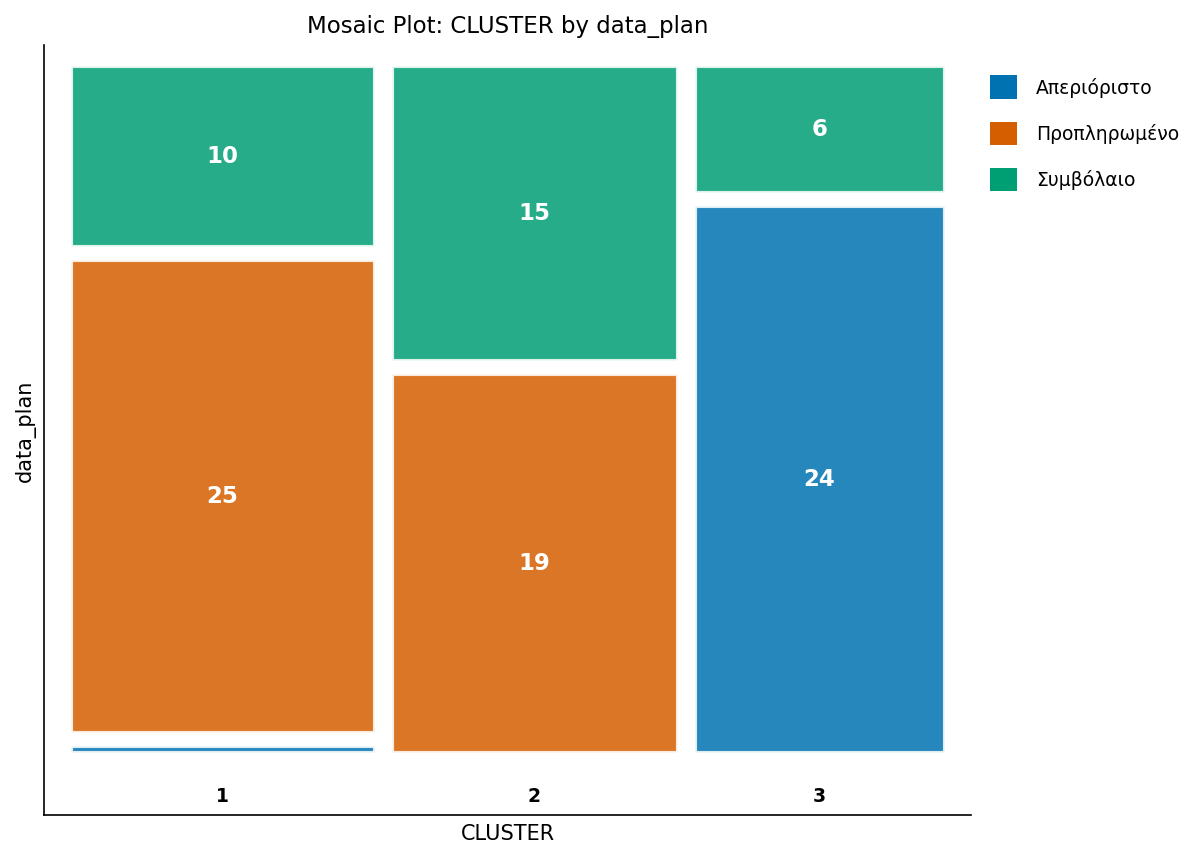

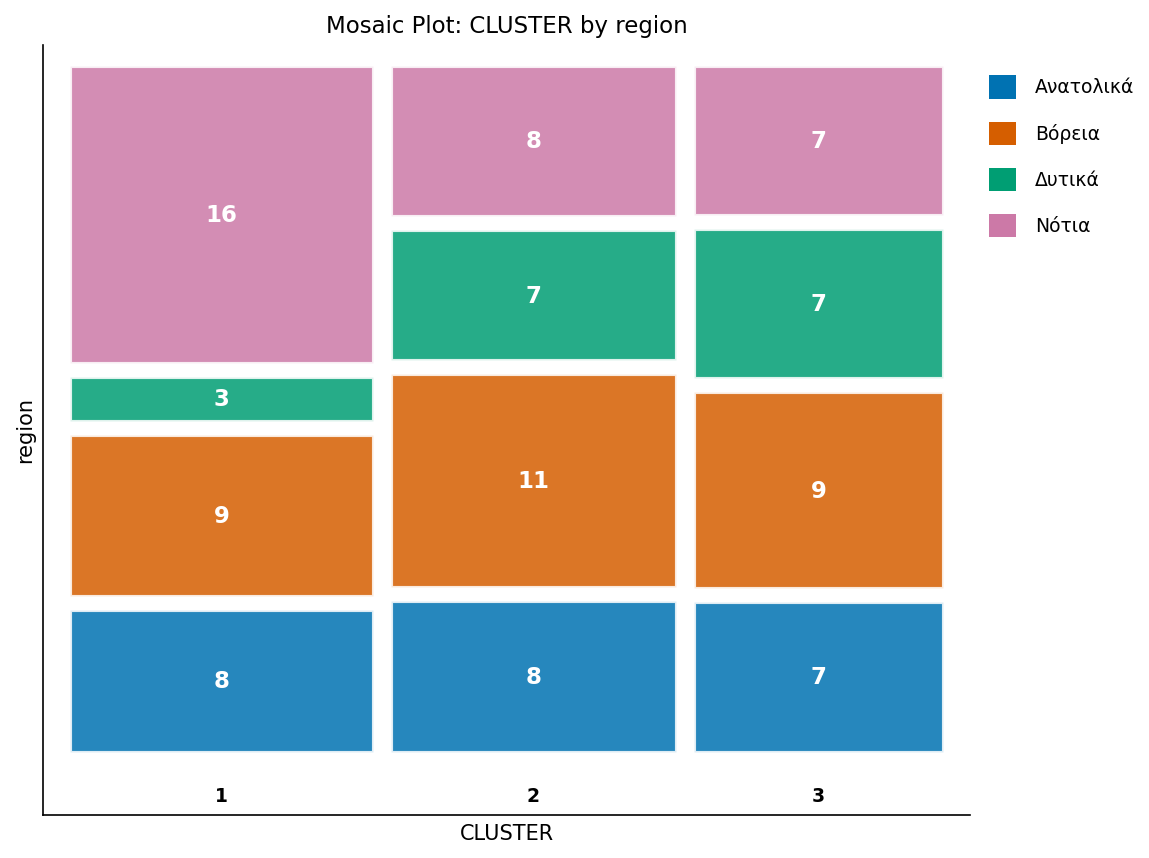

In [6]:
/* Συμπεριφορικό προφίλ: μέσος όρος κάθε χαρακτηριστικού ανά τμήμα */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=profile n mean maxdec=1;
    ΕΤΙΚΕΤΑ tenure_months='Διάρκεια Συνδρομής (μήνες)' monthly_data_gb='Μηνιαία Δεδομένα (GB)'
          voice_minutes='Λεπτά Ομιλίας' sms_count='Αριθμός SMS' intl_minutes='Διεθνή Λεπτά'
          arpu='ARPU ($)' support_calls='Κλήσεις Υποστήριξης' CLUSTER='Τμήμα';
    ΚΛΑΣΗ CLUSTER;
    ΜΕΤΑΒΛΗΤΗ tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
ΕΚΤΕΛΕΣΗ;

/* Κατηγορικό μείγμα εντός κάθε τμήματος */
ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=profile;
    ΕΤΙΚΕΤΑ CLUSTER='Τμήμα' data_plan='Πρόγραμμα' region='Περιοχή';
    TABLES CLUSTER * data_plan / norow nopercent;
    TABLES CLUSTER * region    / norow nopercent;
ΕΚΤΕΛΕΣΗ;

## 7. Οπτικοποίηση των τμημάτων

Μια εικόνα κάνει την τμηματοποίηση απτή. Σχεδιάζουμε την όρεξη για δεδομένα έναντι της χρήσης ομιλίας, χρωματισμένη ανά τμήμα, και προσθέτουμε ένα box plot του ARPU ανά τμήμα ώστε η ιστορία των εσόδων να είναι προφανής με μια ματιά.


NOTE: ODS Graphics is ON (width=720px, height=520px, format=SVG).
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


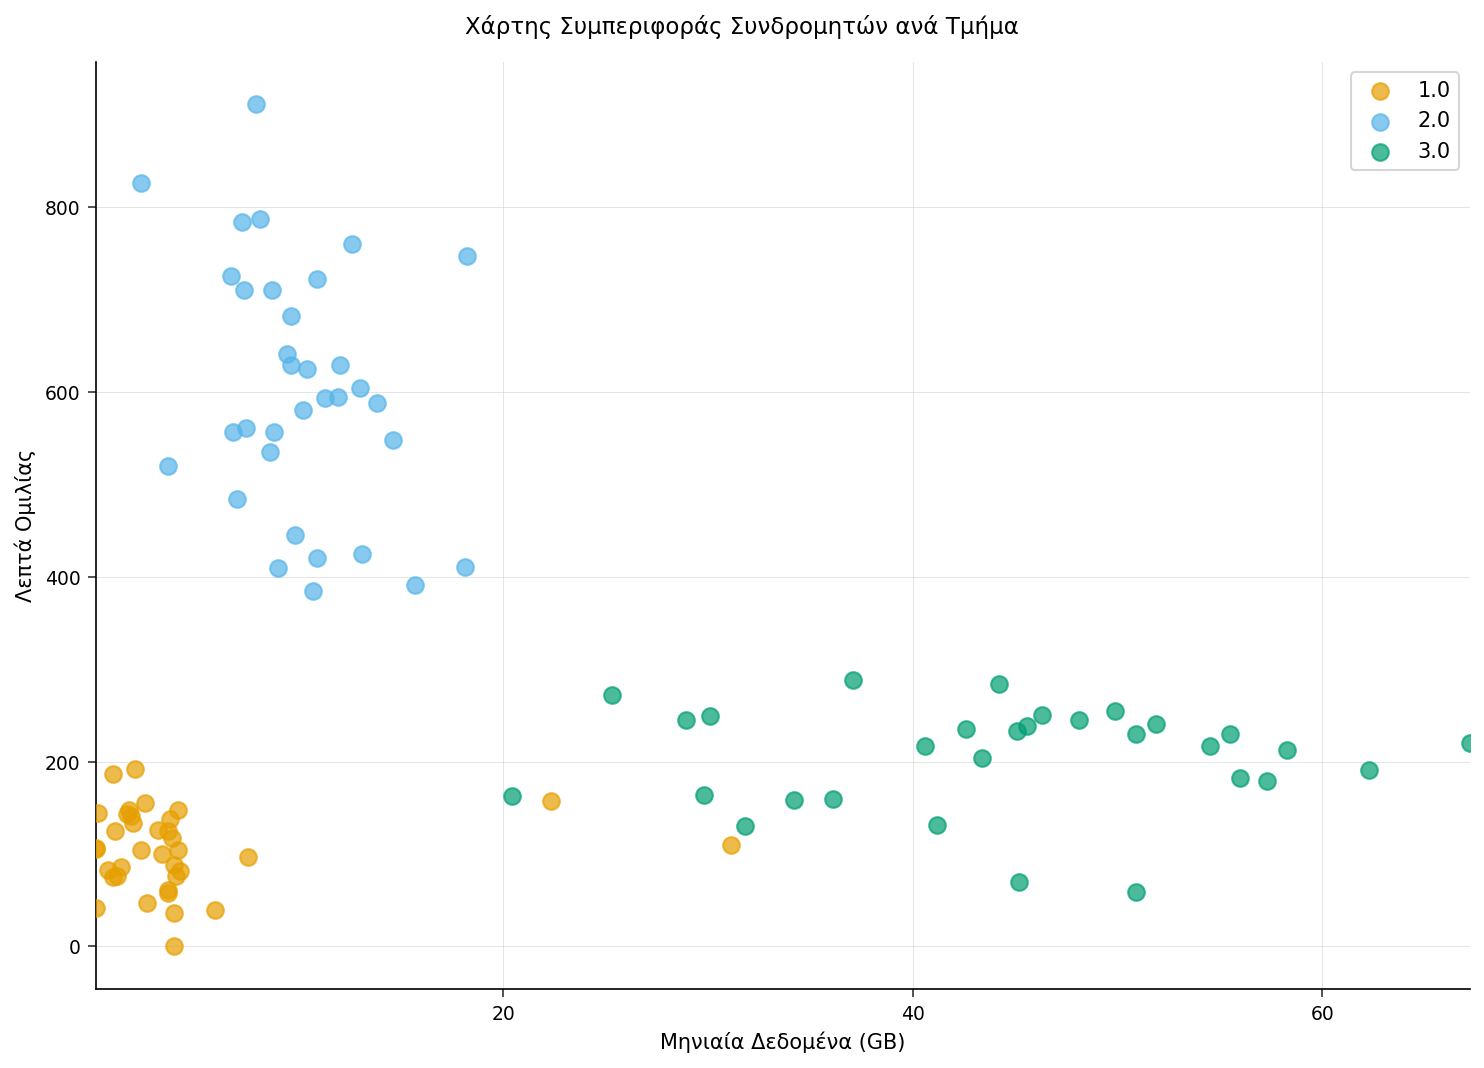

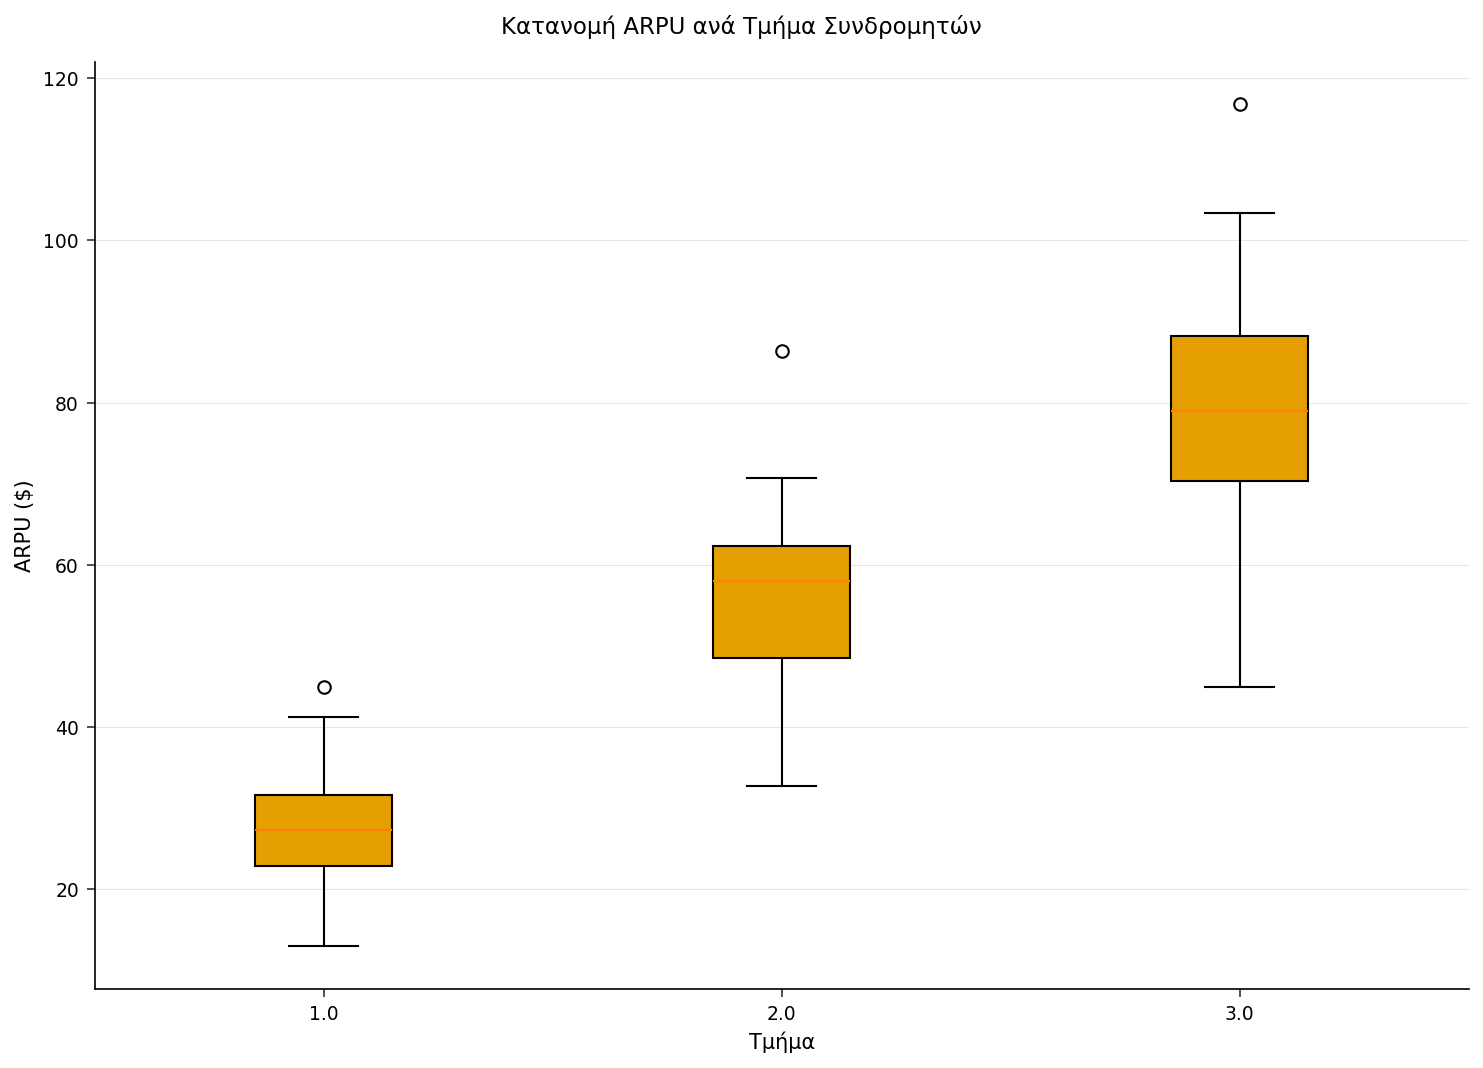

In [7]:
ODS GRAPHICS ON / imagefmt=svg WIDTH=720 HEIGHT=520;

/* Χάρτης συμπεριφοράς: δεδομένα έναντι φωνής, χρωματισμένο ανά τμήμα */
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=profile;
    SCATTER x=monthly_data_gb y=voice_minutes
            / GROUP=CLUSTER
              MARKERATTRS=(size=8 SYMBOL=circlefilled)
              TRANSPARENCY=0.3;
    XAXIS ΕΤΙΚΕΤΑ='Μηνιαία Δεδομένα (GB)' grid;
    YAXIS ΕΤΙΚΕΤΑ='Λεπτά Ομιλίας'     grid;
    TITLE 'Χάρτης Συμπεριφοράς Συνδρομητών ανά Τμήμα';
ΕΚΤΕΛΕΣΗ;

/* Κατανομή εσόδων ανά τμήμα */
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=profile;
    VBOX arpu / category=CLUSTER;
    XAXIS ΕΤΙΚΕΤΑ='Τμήμα';
    YAXIS ΕΤΙΚΕΤΑ='ARPU ($)' grid;
    TITLE 'Κατανομή ARPU ανά Τμήμα Συνδρομητών';
ΕΚΤΕΛΕΣΗ;

## 8. Εξαγωγή των βαθμολογημένων τμημάτων

Τέλος, παραδίδουμε τις αναθέσεις στα επόμενα συστήματα CRM και καμπάνιας. Κρατάμε το αναγνωριστικό, την ετικέτα συστάδας, και τα βασικά συμπεριφορικά πεδία.

In [8]:
/* Διατήρηση των αναθέσεων τμήματος για ενεργοποίηση */
ΔΕΔΟΜΕΝΑ subscriber_segments;
    ΟΡΙΣΜΟΣ profile;
    ΚΡΑΤΗΣΗ subscriber_id CLUSTER tenure_months
         monthly_data_gb voice_minutes arpu data_plan region;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=subscriber_segments(obs=10) noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ CLUSTER='Τμήμα' tenure_months='Διάρκεια Συνδρομής (μήνες)'
          monthly_data_gb='Μηνιαία Δεδομένα (GB)' voice_minutes='Λεπτά Ομιλίας'
          arpu='ARPU ($)' data_plan='Πρόγραμμα' region='Περιοχή';
    TITLE 'Δείγμα Βαθμολογημένων Τμημάτων Συνδρομητών';
ΕΚΤΕΛΕΣΗ;

                                       Δείγμα Βαθμολογημένων Τμημάτων Συνδρομητών                                       

subscriber_id       Τμήμα                        Διάρκεια Συνδρομής (μήνες)                 Μηνιαία Δεδομένα (GB)              Λεπτά Ομιλίας  ARPU ($)                 Πρόγραμμα             Περιοχή
       100001           1                                                30                                   2.3                        104        28  Προπληρωμένο              Νότια
       100002           2                                                 8                                  10.2                        581     57.78  Προπληρωμένο              Δυτικά
       100003           2                                                 8                                  10.7                        385     55.66  Συμβόλαιο                 Βόρεια
       100004           2                                                68                                   7.4              


NOTE: DATA subscriber_segments


NOTE: Read 100 rows from profile.
NOTE: Wrote subscriber_segments (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=subscriber_segments

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Ερμηνεία των αποτελεσμάτων

Η `PROC FASTCLUS` ανέκτησε τρία καθαρά, καλά διαχωρισμένα τμήματα. Η προσαρμογή είναι στέρεη: το **συνολικό R-τετράγωνο είναι 0,575** και το **pseudo-F είναι 65,75**, που σημαίνει ότι οι τρεις συστάδες εξηγούν περίπου το 58% της συνολικής μεταβλητότητας στα τυποποιημένα χαρακτηριστικά. Ο διαχωρισμός οφείλεται σχεδόν αποκλειστικά στα συμπεριφορικά σήματα που μας ενδιαφέρουν -- η `voice_minutes` (R-τετράγωνο 0,858), η `monthly_data_gb` (0,844), και το `arpu` (0,771) φέρουν την τμηματοποίηση, ενώ η `tenure_months` (0,000) και οι `support_calls` (0,193) συνεισφέρουν σχεδόν τίποτα, επιβεβαιώνοντας ότι *πώς* χρησιμοποιεί ένας συνδρομητής το δίκτυο -- όχι πόσο καιρό είναι πελάτης -- καθορίζει τις προσωπικότητες.

Τα τρία τμήματα αντιστοιχίζονται απευθείας σε προσωπικότητες έτοιμες για μάρκετινγκ, με προφίλ εδώ στην αρχική (μη τυποποιημένη) κλίμακα:

| Τμήμα | n (μερίδιο) | Χαρακτηριστική συμπεριφορά | Μείγμα πακέτων | Προσωπικότητα | Προτεινόμενη ενέργεια |
| :-----: | :-------: | ------------------ | -------- | ------- | ---------------- |
| **3** | 30 (30%) | Υψηλότερα δεδομένα: **44,4 GB/μήνα**, κορυφαία δαπάνη **79,1 $ ARPU**, μέτρια ομιλία (205 λεπτά) | 24/30 **Απεριόριστο** | **Streamers υψηλής χρήσης δεδομένων** | Προστασία και αναβάθμιση: ταχύτερα πακέτα, δέσμες περιεχομένου, αναβαθμίσεις συσκευών |
| **2** | 34 (34%) | Υψηλότερη ομιλία **603 λεπτά/μήνα**, **214 SMS**, **106 διεθνή λεπτά**, μέση δαπάνη **55,9 $ ARPU** | Προπληρωμένο + Συμβόλαιο, **χωρίς Απεριόριστο** | **Παραδοσιακοί χρήστες κεντρικά στη φωνή** | Πρόσθετα διεθνών κλήσεων, οικογενειακές/φωνητικές δέσμες, ανταμοιβές πιστότητας |
| **1** | 36 (36%) | Χαμηλότερη χρήση: **4,0 GB**, 104 λεπτά ομιλίας, χαμηλότερη δαπάνη **28,0 $ ARPU** | 25/36 **Προπληρωμένο** | **Ελαφριά / χαμηλή χρήση** | Προσαρμογή μεγέθους πακέτων, υπενθυμίσεις autopay, φθηνά αρχικά πακέτα δεδομένων για ανάπτυξη χρήσης |

Το μείγμα πακέτων επιβεβαιώνει την συμπεριφορική ανάγνωση: το τμήμα υψηλής χρήσης δεδομένων βρίσκεται συντριπτικά σε πακέτα **Απεριόριστο** (24 από τα 30), το τμήμα κεντρικά στη φωνή δεν έχει **καθόλου** συνδρομητές Απεριορίστου, και το τμήμα χαμηλής χρήσης είναι κυρίως **Προπληρωμένο** (25 από τα 36). Η περιοχή, αντίθετα, κατανέμεται ομοιόμορφα και στα τρία τμήματα -- η γεωγραφία δεν είναι εδώ συμπεριφορικός παράγοντας, κάτι που είναι από μόνο του ένα χρήσιμο εύρημα για τη στόχευση καμπανιών.

**Γιατί η `PROC FASTCLUS` ταιριάζει σε αυτό το πρόβλημα.** Εκτελεί ασύνδετη k-means περνώντας πάνω από τα δεδομένα αντί να υλοποιεί έναν πλήρη πίνακα αποστάσεων, οπότε το ίδιο πρόγραμμα που τμηματοποίησε αυτούς τους 100 συνδρομητές κλιμακώνεται σε πολύ μεγαλύτερες βάσεις. Η τυποποίηση με την `PROC STDIZE` πρώτα αφαίρεσε την προκατάληψη κλίμακας μονάδων μεταξύ gigabyte, λεπτών, και δολαρίων, ώστε κάθε συμπεριφορά να συνεισφέρει εξίσου στην Ευκλείδεια απόσταση· τα διαγνωστικά R-τετράγωνο μας είπαν στη συνέχεια *ποια* χαρακτηριστικά πράγματι οδήγησαν τον διαχωρισμό. Η βαθμολογημένη έξοδος -- μια ετικέτα `CLUSTER` για κάθε συνδρομητή -- εντάσσεται απευθείας σε διοχετεύσεις ενεργοποίησης, κλείνοντας τον κύκλο από την ακατέργαστη συμπεριφορά στην στοχευμένη προσφορά.

---

<div style="font-size:11px;color:#9e9e9e">Αυτό το notebook παρέχεται μόνο για επίδειξη. Τα δεδομένα είναι συνθετικά και τα ευρήματα δεν αποτελούν επιχειρηματική συμβουλή.</div>